# Базовые методы детекции аномалий и их метрики (max-pooling)

## Цель эксперимента

Изучить распределение эмбеддингов, полученных с помощью max pooling. Оценить возможность решения задачи OOD (Out of Destribution) с помощью базовых методов классификации на этих эмбеддингах.

## Детали
### Методы:
1. Mahalanobis Distance (с LedoitWolf). Модель учит расспределение и далее считает расстояние до тестовых эмбеддингов.
2. Isolation Forest. Количество разрезов для изоляции.
3. kNN Distance. Аномалии далеко от своих ближайших соседей.
4. Local Outlier Factor (LOF). Сравнивает плотность точки относительно плотности её соседей. Если точка в регионе с резко меньшей плотностью, чем у соседей, то она аномальная.
5. Autoencoder. Учится хорошо восстанавливать нормальные данные.

### Энкодеры
1. all-MiniLM-L6-v2
2. all-mpnet-base-v2
3. e5-base

### Эмбеддинги - покомпонентный максимум эмбеддингов предложений (max-pooling)

Что кодирует max-pooling:
1. Самые сильные/доминирующие признаки предложений по каждому измерению эмбеддинга, игнорируя порядок слов.

Что теряет:
1. Порядок предложений
2. Связи между предложениями.
3. Слабые признаки.

### Данные
- TRAIN: Живые эссе с Ivy Panda, 90805 штук.
- TEST: Живые эссе с Ivy Panda + сгенерированные (Mistral 7B, Llama 3 13B, ChatGPT, DeepSeek). Пропорции 50/50. Суммарно 74976 штук.

In [1]:
ENCODERS = [
    "all-MiniLM-L6-v2",
    "all-mpnet-base-v2",
    "intfloat/e5-base",
]

KNN_N_NEIGHBORS = 5
LOF_N_NEIGHBORS = 20
ENCODE_BATCH_SIZE = 32
AE_EPOCH_N = 5
AE_BATCH_SIZE = 8192

DEVICE = "mps"

CACHE_DIR = "../models/emb_cache"

In [2]:
import numpy as np
from sklearn.covariance import LedoitWolf
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, auc, precision_recall_curve, silhouette_score, davies_bouldin_score
import torch
import torch.nn as nn
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import re
from sklearn.metrics import pairwise_distances
import random
import hashlib
from tqdm import tqdm

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Загрузка датасетов

In [5]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)
df_train, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [6]:
print(f"Загружено {len(df_train)} записей Ivy Panda (живые, train)")
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 90805 записей Ivy Panda (живые, train)
Загружено 74976 записей (синтетика + живые, test)


### Необходимые для моделей классы

In [7]:
class AE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
        )
        self.dec = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, dim),
        )
    def forward(self, x):
        return self.dec(self.enc(x))

## Функции визуализации

### 1. `plot_score_distribution`

Функция строит распределения аномальных скорингов отдельно для нормальных объектов (живых текстов) и аномалий (синтетических).

Если кривые мало пересекаются, метод хорошо отделяет классы.

### 2. `plot_roc_pr`

Функция строит:

#### ROC-кривые

Диагональная линия соответствует случайному классификатору. ROC показывает способность метода отделять классы при различных порогах.

#### Precision–Recall кривые

Дополнительно строятся PR-кривые и вычисляется AP (average precision).

### 3. `plot_tsne`

Функция визуализирует данные в двумерном пространстве:

1. Случайно выбирается подвыборка (до 2000 объектов).
2. Сначала применяется PCA (до 30 компонент) для снижения размерности.
3. Затем применяется t-SNE для отображения в 2D.

На графике точки раскрашены по классам.

Визуализация позволяет оценить:

* формируют ли аномалии отдельный кластер,
* есть ли визуально различимая структура данных.

### 4. `plot_correlation`

Функция вычисляет корреляционную матрицу между скорингами разных методов.

### 5. `plot_pca_kde`

1. Понижает размерность данных до двух компонент с помощью PCA.
2. Строит двумерные KDE-плотности отдельно для каждого класса.

### 6. `plot_cosine_dists`

Функция анализирует попарные косинусные расстояния:

* между нормальными объектами (H–H),
* между аномалиями (A–A),
* между нормальными и аномалиями (H–A).

### 7. `plot_centroid_heatmap`

1. Вычисляет центроид каждого класса.
2. Считает косинусное сходство объектов своего класса с соответствующим центроидом.
3. Строит распределения этих сходств.


In [8]:
def plot_score_distribution(scores, y, title):
    plt.figure(figsize=(8,4))
    sns.kdeplot(scores[y==0], label="normal", fill=True, alpha=0.4)
    sns.kdeplot(scores[y==1], label="anomaly", fill=True, alpha=0.4)
    plt.title(title)
    plt.xlabel("score")
    plt.ylabel("density")
    plt.legend()
    plt.show()

def plot_roc_pr(scores_dict, y):
    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        fpr, tpr, _ = roc_curve(y, s)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("ROC Curves")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8,4))
    for name, s in scores_dict.items():
        pr, rc, _ = precision_recall_curve(y, s)
        ap = average_precision_score(y, s)
        plt.plot(rc, pr, label=f"{name} (AP={ap:.3f})")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title("Precision-Recall Curves")
    plt.legend()
    plt.show()

def plot_tsne(X, y, title):
    idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
    Xsub = X[idx]
    ysub = y[idx]
    
    Xp = PCA(30).fit_transform(Xsub)
    Xt = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(Xp)
    
    plt.figure(figsize=(8,4))
    plt.scatter(Xt[ysub==0,0], Xt[ysub==0,1], s=10, alpha=0.5, label='normal')
    plt.scatter(Xt[ysub==1,0], Xt[ysub==1,1], s=10, alpha=0.7, label='anomaly')
    plt.title(title)
    plt.legend()
    plt.show()

def plot_correlation(scores_dict):
    mat = np.vstack(list(scores_dict.values()))
    corr = np.corrcoef(mat)
    
    plt.figure(figsize=(8,4))
    sns.heatmap(corr, annot=True, xticklabels=scores_dict.keys(), yticklabels=scores_dict.keys())
    plt.title("Score Correlation Heatmap")
    plt.show()

def plot_pca_kde(X, y, title):
    Z = PCA(n_components=2).fit_transform(X)
    df = pd.DataFrame({"PC1": Z[:,0], "PC2": Z[:,1], "label": y})
    
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df[df.label==0], x="PC1", y="PC2", fill=True, cmap="Blues", alpha=0.6, levels=30)
    sns.kdeplot(data=df[df.label==1], x="PC1", y="PC2", fill=True, cmap="Reds", alpha=0.6, levels=30)
    plt.title(title)
    plt.show()

def plot_cosine_dists(X, y, title):
    X_h = X[y==0]
    X_ai = X[y==1]

    D_hh = pairwise_distances(X_h[:2000], X_h[:2000], metric="cosine").flatten()
    D_aa = pairwise_distances(X_ai[:2000], X_ai[:2000], metric="cosine").flatten()
    D_ha = pairwise_distances(X_h[:2000], X_ai[:2000], metric="cosine").flatten()

    plt.figure(figsize=(8,4))
    sns.kdeplot(D_hh, label="H-H", alpha=0.7)
    sns.kdeplot(D_aa, label="A-A", alpha=0.7)
    sns.kdeplot(D_ha, label="H-A", alpha=0.7)
    plt.title(title)
    plt.legend()
    plt.show()

def plot_centroid_heatmap(X, y, title):
    c0 = X[y==0].mean(axis=0)
    c1 = X[y==1].mean(axis=0)
    
    D0 = X[y==0] @ c0 / (np.linalg.norm(X[y==0], axis=1)*np.linalg.norm(c0))
    D1 = X[y==1] @ c1 / (np.linalg.norm(X[y==1], axis=1)*np.linalg.norm(c1))

    plt.figure(figsize=(8,4))
    sns.kdeplot(D0, label="Human → Human centroid")
    sns.kdeplot(D1, label="AI → AI centroid")
    plt.title(title)
    plt.legend()
    plt.show()

In [9]:
def eval_scores(name, scores, y):
    auc = roc_auc_score(y, scores)
    ap = average_precision_score(y, scores)
    print(f"{name:20s} | ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")

def print_cluster_scores(X, y, title):
    print(title)
    print("Silhouette:", silhouette_score(X, y))
    print("Davies-Bouldin:", davies_bouldin_score(X, y))

### Метод получения эмбеддингов

1. Текст предварительно разбивается на предложения (переход на новую строку считается границей предложения).
2. Для каждого предложения отдельно вычисляется эмбеддинг.
3. Итоговый эмбеддинг всего текста получается покомпоментным максимумом эмбеддингов всех предложений.

In [10]:
def _compute_hash(data, model_name):
    h = hashlib.sha256()
    h.update(model_name.encode("utf-8"))

    for text in data:
        h.update(text.encode("utf-8"))

    return h.hexdigest()[:32]


def get_embeddings(model, data, model_name, cache_dir=CACHE_DIR):
    safe_model_name = model_name.replace("/", "__")
    
    os.makedirs(cache_dir, exist_ok=True)

    cache_key = _compute_hash(data, model_name)
    cache_path = os.path.join(cache_dir, f"{safe_model_name}_{cache_key}.npy")
    cache_counts_path = os.path.join(cache_dir, f"{safe_model_name}_counts_{cache_key}.npy")

    if os.path.exists(cache_path) and os.path.exists(cache_counts_path):
        print(f"Loading embeddings from cache for {model_name}...")
        all_embeddings = np.load(cache_path)
        sentence_counts = np.load(cache_counts_path)
    else:
        print(f"Computing embeddings for {model_name}...")
    
        all_sentences = []
        sentence_counts = []
        for text in tqdm(data):
            text = re.sub(r"\n+", ". ", text)
            sentences = nltk.sent_tokenize(text)
    
            if "e5" in model_name:
                sentences = [f"passage: {s}" for s in sentences]
    
            all_sentences.extend(sentences)
            sentence_counts.append(len(sentences))
    
        all_embeddings = model.encode(
            all_sentences,
            batch_size=ENCODE_BATCH_SIZE,
            normalize_embeddings=True,
            show_progress_bar=True,
            device=DEVICE,
        )

        np.save(cache_path, all_embeddings)
        np.save(cache_counts_path, sentence_counts)

    result = []
    idx = 0
    for count in tqdm(sentence_counts):
        embeddings = all_embeddings[idx: idx + count]
        result.append(np.max(embeddings, axis=0))
        idx += count

    result = np.array(result, dtype=np.float32)

    return result

### Методы классификации

In [11]:
def mahalanobis_score(X_train, X_test):
    lw = LedoitWolf().fit(X_train)
    return lw.mahalanobis(X_test)

def isolation_forest_score(X_train, X_test):
    iso = IsolationForest(
        contamination='auto',
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    )
    iso.fit(X_train)
    return -iso.decision_function(X_test)

def knn_score(X_train, X_test):
    nn = NearestNeighbors(
        n_neighbors=KNN_N_NEIGHBORS,
        n_jobs=-1
    )
    nn.fit(X_train)
    d, _ = nn.kneighbors(X_test)
    return d.mean(axis=1)

def lof_score(X_train, X_test):
    lof = LocalOutlierFactor(
        n_neighbors=LOF_N_NEIGHBORS,
        novelty=True,
        n_jobs=-1
    )
    lof.fit(X_train)
    return -lof.decision_function(X_test)

def ae_score(X_train, X_test):
    d = X_train.shape[1]
    
    ae = AE(d).to(DEVICE)
    ae.train()
    
    opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(Xtr)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=AE_BATCH_SIZE,
        shuffle=True,
        drop_last=False
    )

    for epoch in range(AE_EPOCH_N):
        for (batch,) in loader:
            batch = batch.to(DEVICE)

            out = ae(batch)
            loss = loss_fn(out, batch)

            opt.zero_grad()
            loss.backward()
            opt.step()

    ae.eval()
    Xe = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        recon = ae(Xe).cpu().numpy()

    return np.mean((X_test - recon) ** 2, axis=1)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading embeddings from cache for all-MiniLM-L6-v2...


100%|████████████████████████████████████████████████████████████████████████| 90805/90805 [00:00<00:00, 158664.35it/s]


Loading embeddings from cache for all-MiniLM-L6-v2...


100%|████████████████████████████████████████████████████████████████████████| 74976/74976 [00:00<00:00, 219992.89it/s]


X_train: (90805, 384)
X_test: (74976, 384)
y_test: (74976,) | аномалий: 37488


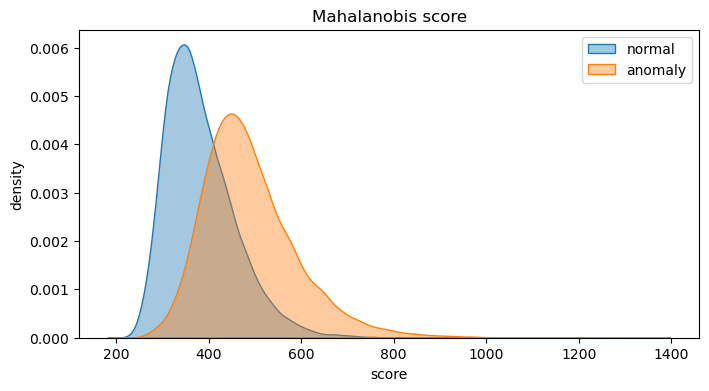

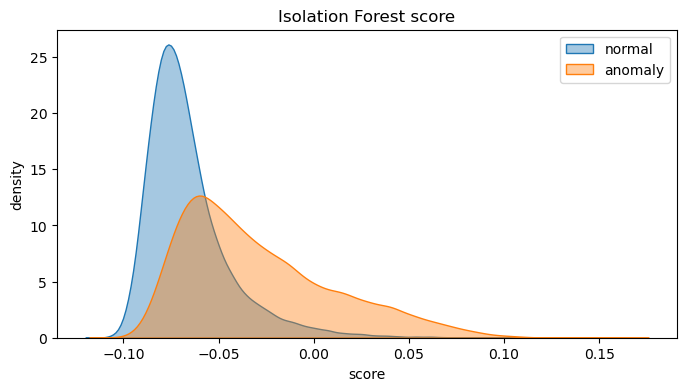

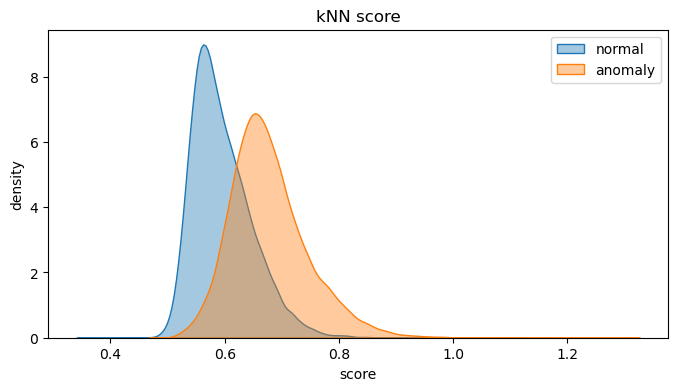

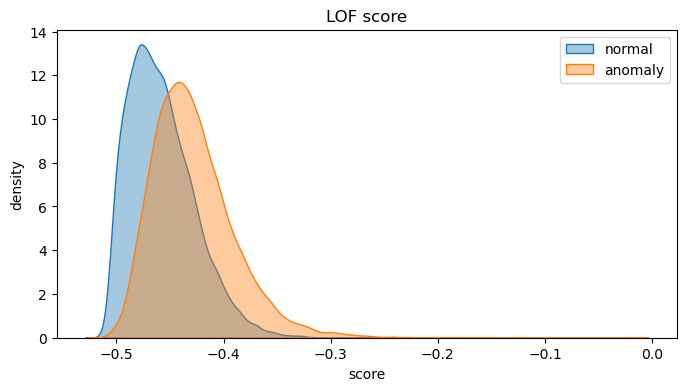

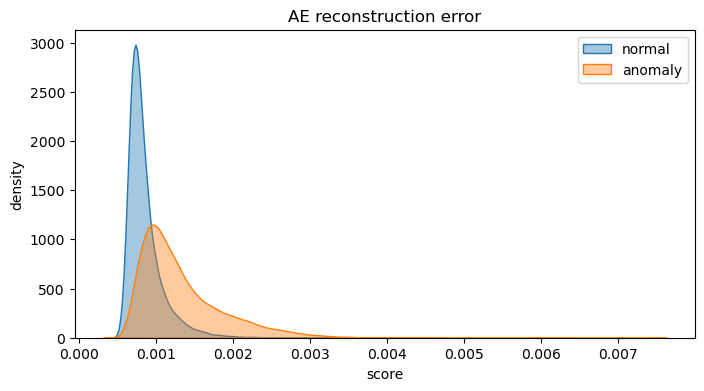

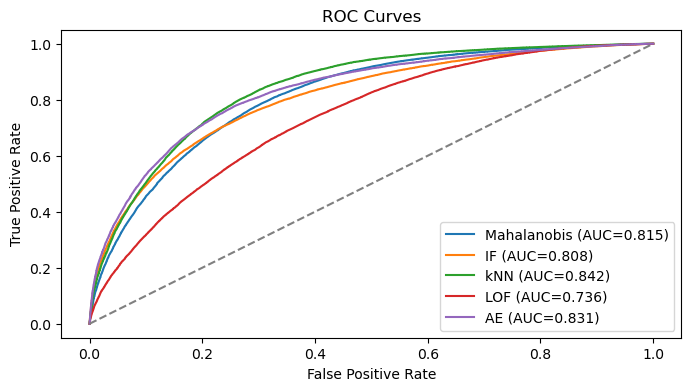

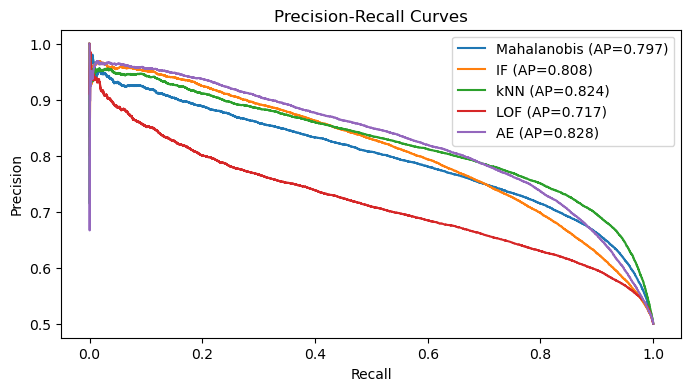

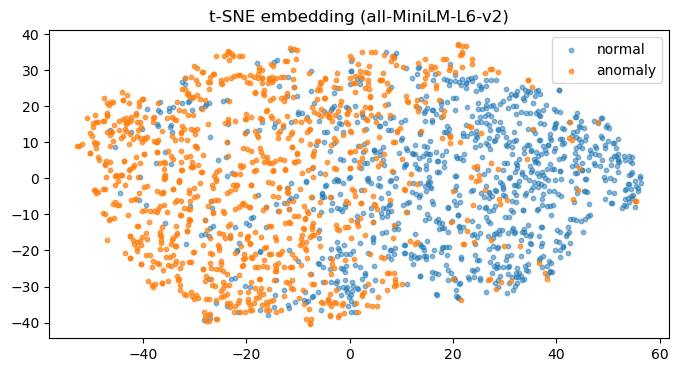

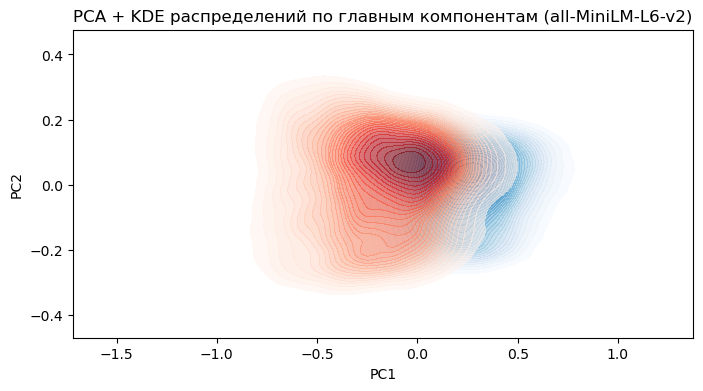

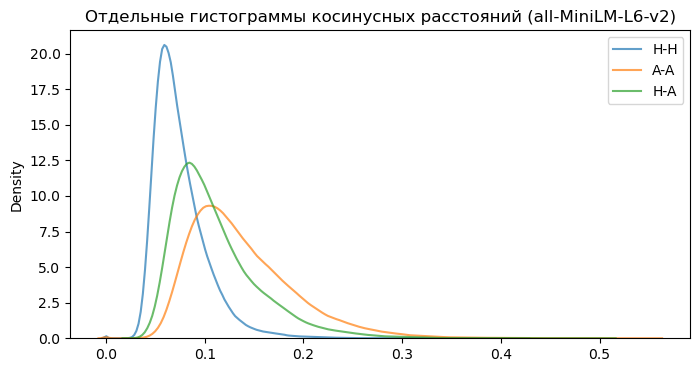

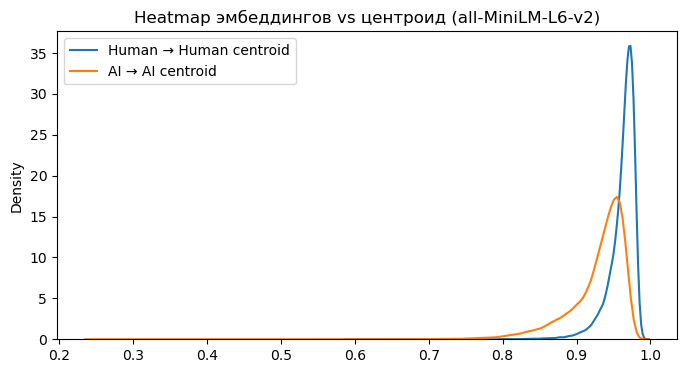

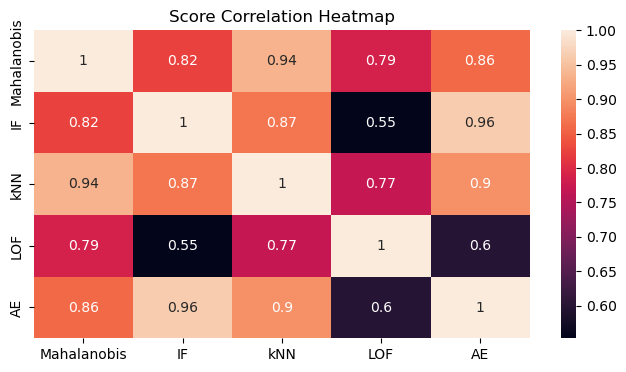

Кластерные метрики (all-MiniLM-L6-v2)
Silhouette: 0.06841983646154404
Davies-Bouldin: 3.321265452687482


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading embeddings from cache for all-mpnet-base-v2...


100%|█████████████████████████████████████████████████████████████████████████| 90805/90805 [00:05<00:00, 17069.13it/s]


Loading embeddings from cache for all-mpnet-base-v2...


100%|████████████████████████████████████████████████████████████████████████| 74976/74976 [00:00<00:00, 146163.93it/s]


X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


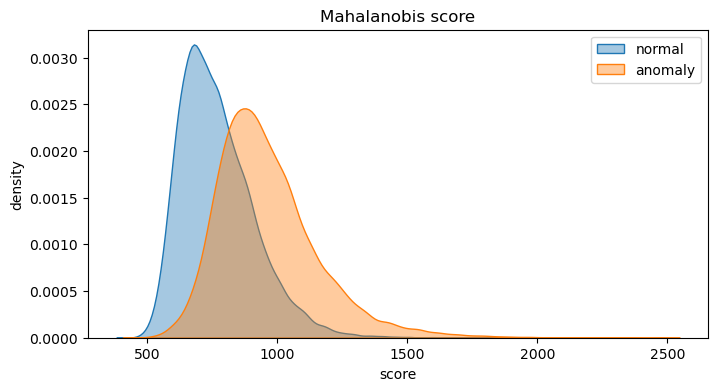

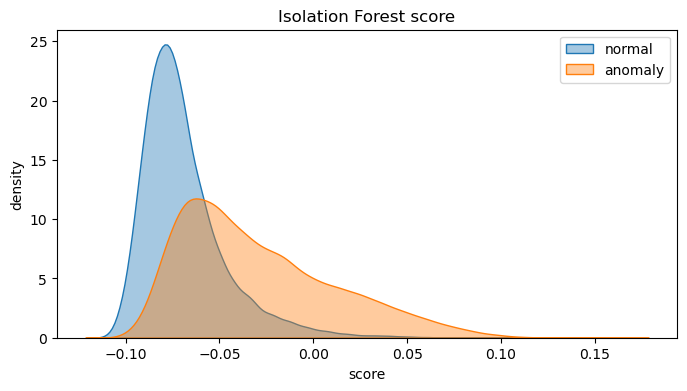

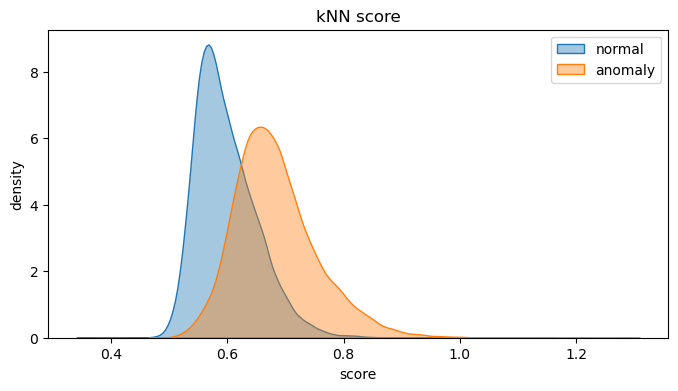

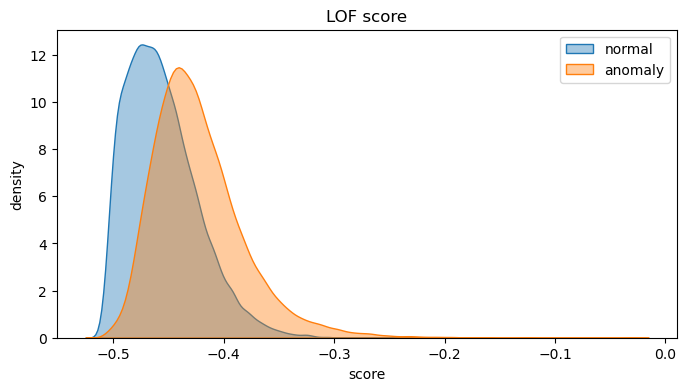

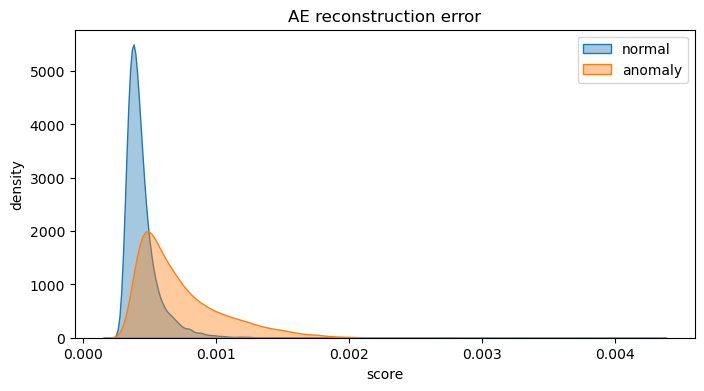

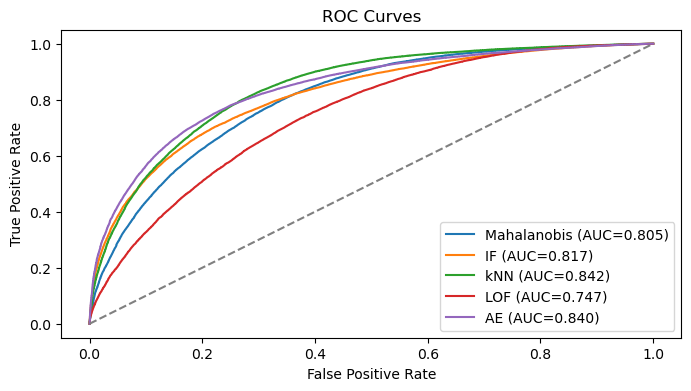

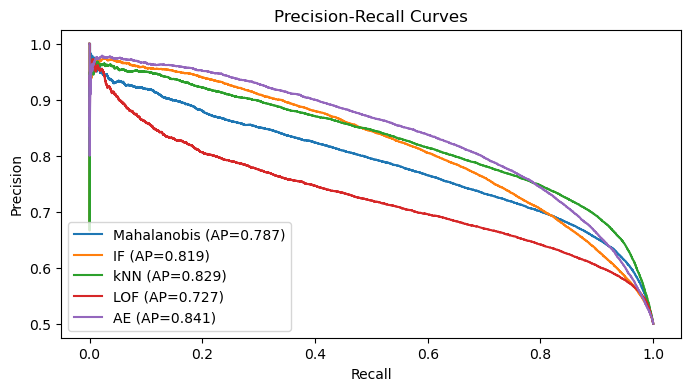

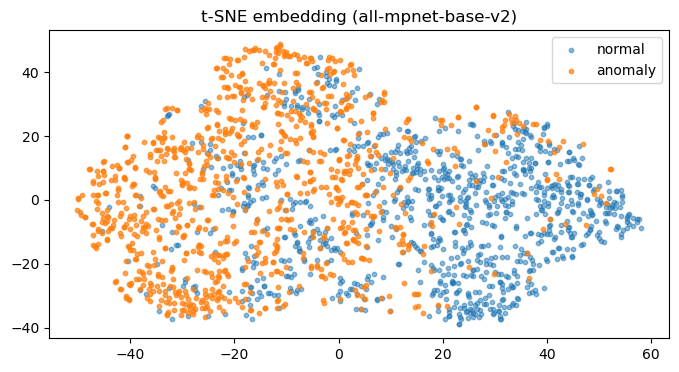

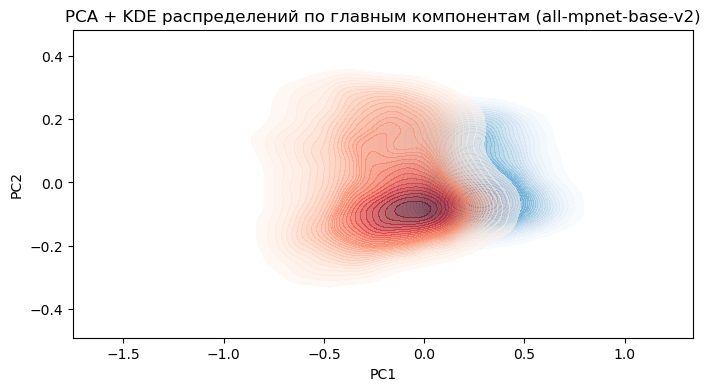

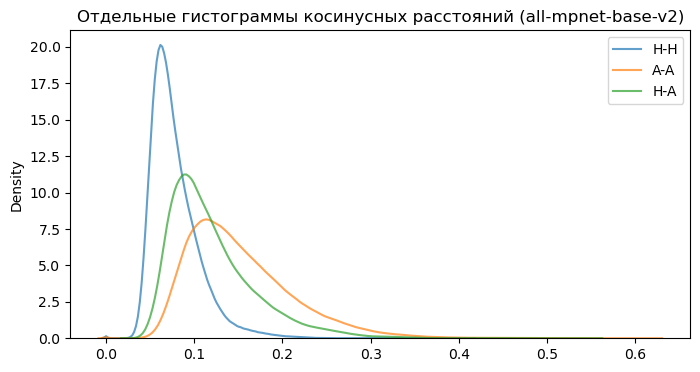

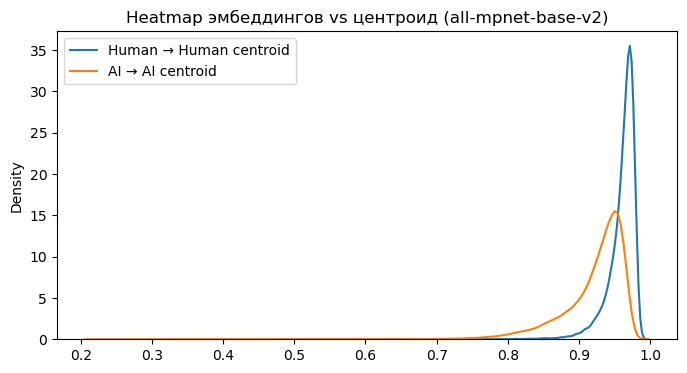

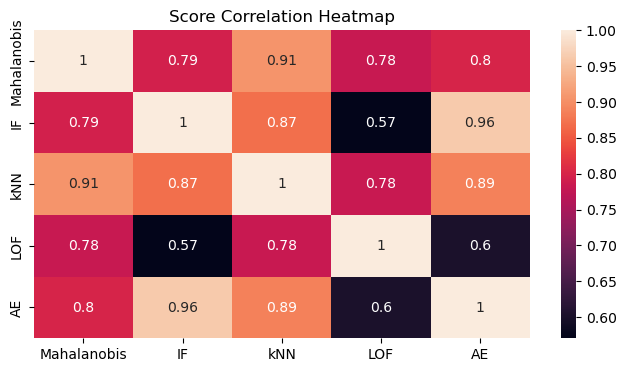

Кластерные метрики (all-mpnet-base-v2)
Silhouette: 0.075346440076828
Davies-Bouldin: 3.147911671052023


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading embeddings from cache for intfloat/e5-base...


100%|█████████████████████████████████████████████████████████████████████████| 90805/90805 [00:04<00:00, 19540.74it/s]


Loading embeddings from cache for intfloat/e5-base...


100%|████████████████████████████████████████████████████████████████████████| 74976/74976 [00:00<00:00, 147029.09it/s]


X_train: (90805, 768)
X_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


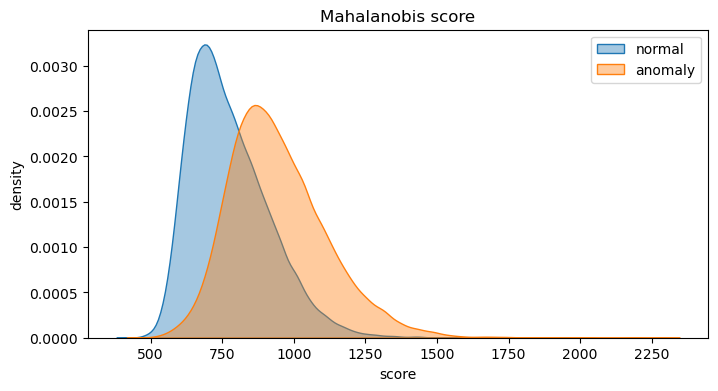

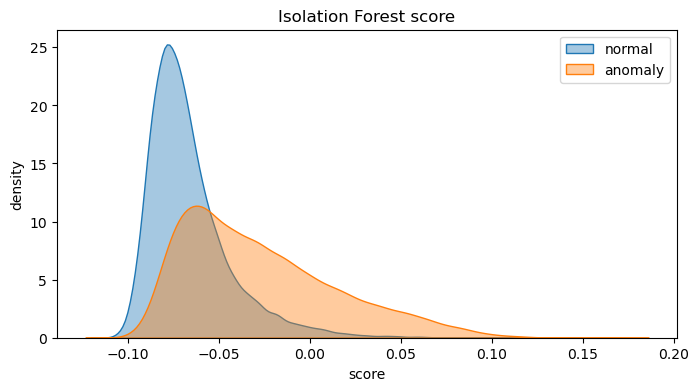

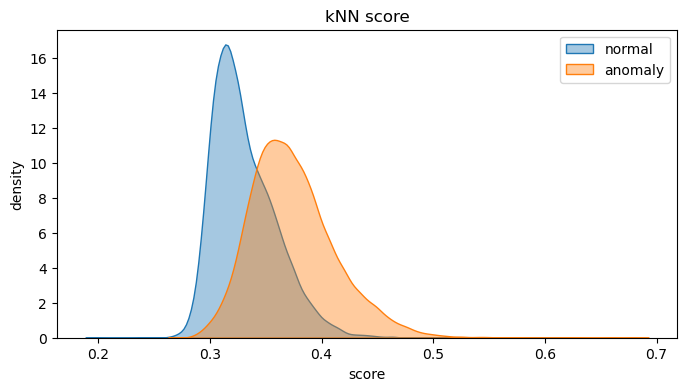

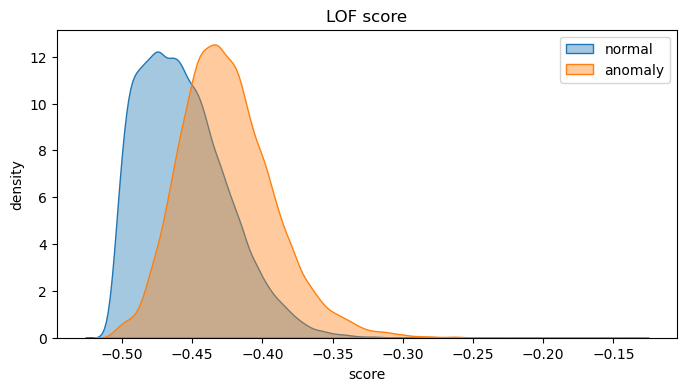

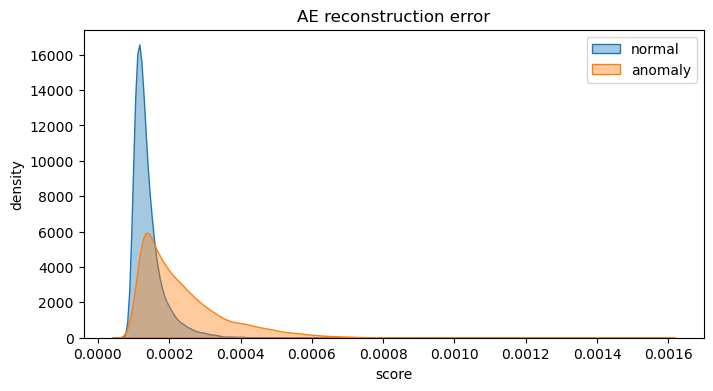

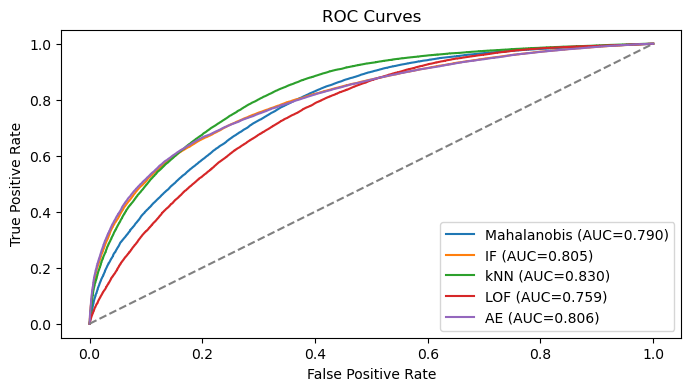

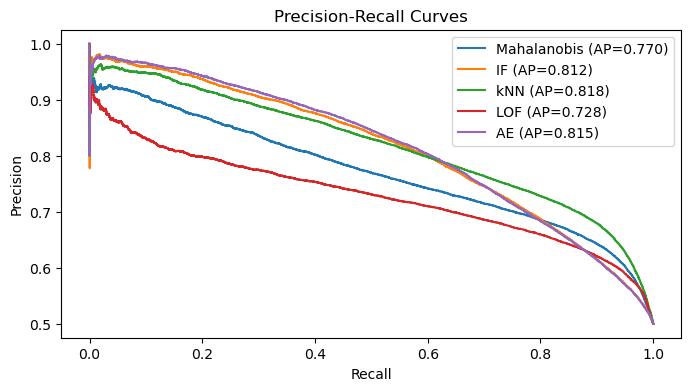

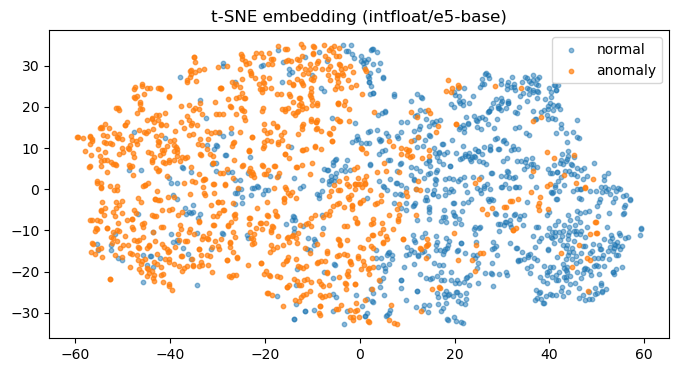

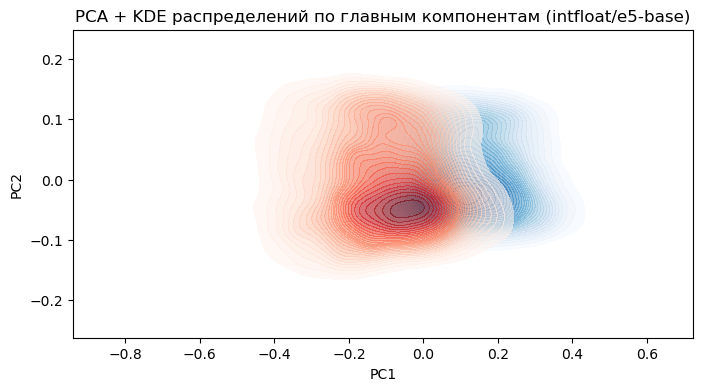

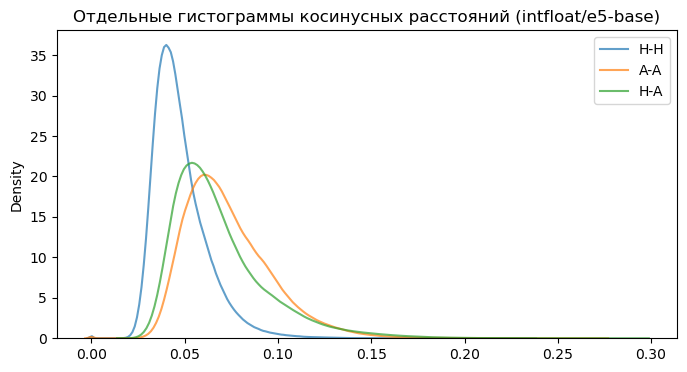

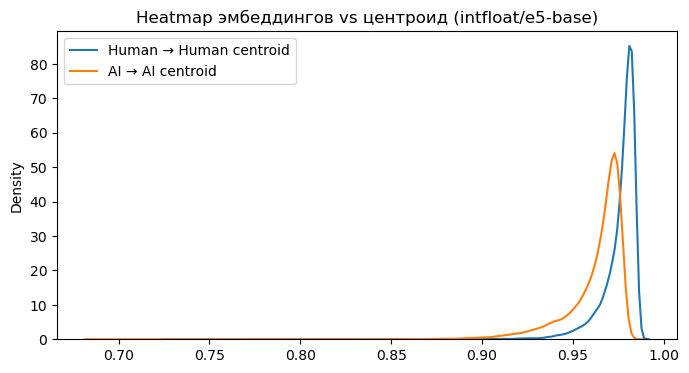

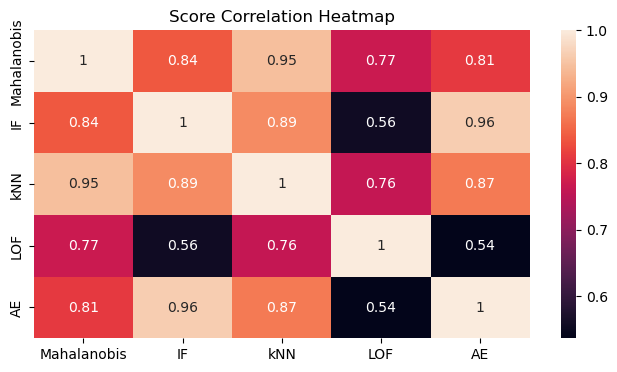

Кластерные метрики (intfloat/e5-base)
Silhouette: 0.08166641741991043
Davies-Bouldin: 2.98556656683316


In [12]:
results = dict()

for model_name in ENCODERS:
    model = SentenceTransformer(model_name)

    X_train = get_embeddings(model, df_train['text'].tolist(), model_name)
    
    X_test = get_embeddings(model, df_all['text'].tolist(), model_name)
    y_test = df_all['label'].values.astype(int)

    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    # 1. Mahalanobis Distance
    mahal_scores = mahalanobis_score(X_train, X_test)
    
    # 2. Isolation Forest
    iso_scores = isolation_forest_score(X_train, X_test)
    
    # 3. kNN Distance
    knn_scores = knn_score(X_train, X_test)
    
    # 4. Local Outlier Factor (LOF)
    lof_scores = lof_score(X_train, X_test)
    
    # 5. Autoencoder
    ae_scores = ae_score(X_train, X_test)

    plot_score_distribution(mahal_scores, y_test, "Mahalanobis score")
    plot_score_distribution(iso_scores, y_test, "Isolation Forest score")
    plot_score_distribution(knn_scores, y_test, "kNN score")
    plot_score_distribution(lof_scores, y_test, "LOF score")
    plot_score_distribution(ae_scores, y_test, "AE reconstruction error")

    scores = {
        "Mahalanobis": mahal_scores,
        "IF": iso_scores,
        "kNN": knn_scores,
        "LOF": lof_scores,
        "AE": ae_scores
    }
    plot_roc_pr(scores, y_test)
    plot_tsne(X_test, y_test, f"t-SNE embedding ({model_name})")
    plot_pca_kde(X_test, y_test, f"PCA + KDE распределений по главным компонентам ({model_name})")
    plot_cosine_dists(X_test, y_test, f"Отдельные гистограммы косинусных расстояний ({model_name})")
    plot_centroid_heatmap(X_test, y_test, f"Heatmap эмбеддингов vs центроид ({model_name})")
    plot_correlation(scores)

    print_cluster_scores(X_test, y_test, f"Кластерные метрики ({model_name})")

    results[model_name] = {
        "Mahalanobis": [mahal_scores, y_test],
        "IsolationForest": [iso_scores, y_test],
        "kNN distance": [knn_scores, y_test],
        "LOF": [lof_scores, y_test],
        "Autoencoder": [ae_scores, y_test],
    }

## Итого

In [13]:
for model_name, model_result in results.items():
    print(f"\n=== Результат ({model_name}) ===")
    
    for method_name, scores in model_result.items():
        eval_scores(method_name, scores[0], scores[1])

    print("\n")


=== Результат (all-MiniLM-L6-v2) ===
Mahalanobis          | ROC-AUC: 0.8147 | PR-AUC: 0.7966
IsolationForest      | ROC-AUC: 0.8079 | PR-AUC: 0.8076
kNN distance         | ROC-AUC: 0.8419 | PR-AUC: 0.8239
LOF                  | ROC-AUC: 0.7356 | PR-AUC: 0.7171
Autoencoder          | ROC-AUC: 0.8315 | PR-AUC: 0.8277



=== Результат (all-mpnet-base-v2) ===
Mahalanobis          | ROC-AUC: 0.8051 | PR-AUC: 0.7874
IsolationForest      | ROC-AUC: 0.8167 | PR-AUC: 0.8191
kNN distance         | ROC-AUC: 0.8421 | PR-AUC: 0.8285
LOF                  | ROC-AUC: 0.7467 | PR-AUC: 0.7266
Autoencoder          | ROC-AUC: 0.8402 | PR-AUC: 0.8412



=== Результат (intfloat/e5-base) ===
Mahalanobis          | ROC-AUC: 0.7895 | PR-AUC: 0.7704
IsolationForest      | ROC-AUC: 0.8049 | PR-AUC: 0.8115
kNN distance         | ROC-AUC: 0.8300 | PR-AUC: 0.8176
LOF                  | ROC-AUC: 0.7595 | PR-AUC: 0.7282
Autoencoder          | ROC-AUC: 0.8059 | PR-AUC: 0.8148




## Результаты

Лучшие значения ROC-AUC для различных моделей:
```
=== Результат (sentence-transformers/all-MiniLM-L6-v2) ===
kNN distance         | ROC-AUC: 0.8419 | PR-AUC: 0.8239

=== Результат (sentence-transformers/all-mpnet-base-v2) ===
kNN distance         | ROC-AUC: 0.8421 | PR-AUC: 0.8285

=== Результат (intfloat/e5-base) ===
kNN distance         | ROC-AUC: 0.8300 | PR-AUC: 0.8176

```

## Вывод

Предложенный в эксперименте метод показал показатели качества ниже, чем у бейзлайна с использованием mean-pooling. Кластеры, соответствующие различным классам, в целом различимы, однако между ними сохраняется заметное перекрытие.

Проведён сравнительный анализ нескольких методов агрегации эмбеддингов. По результатам эксперимента наилучшие показатели продемонстрировал метод k ближайших соседей (kNN distance).